# 11 — Cross-Validation: Re-evaluating All Models Properly

**Why this notebook exists**

In notebooks 08 and 10, each model was tested on **one** 80/20 split, which means only **8 test passages**.
With 8 passages, one mistake changes accuracy by 12.5%, so the results depend heavily on luck.

Here we:

1. **Show the problem**: the same model, 50 different random splits
2. **Fix it**: repeated stratified 5-fold cross-validation (5 folds × 20 repeats = 100 tests per model)
3. **Fix a small leak**: TF-IDF is now fitted *inside* each training fold (a `Pipeline`), so it never sees test passages
4. **Find the hardest passages**: which passages are misclassified most often, with passage IDs
5. **Sort feature importance by weight** (not alphabetically) to see what the model actually learned

## 1. Setup

In [1]:

import sys
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    !pip install -q sentence-transformers

In [2]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, make_scorer, precision_score, recall_score
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore")
SEED = 42

RESULTS_DIR = Path("results")
FIG_DIR = RESULTS_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
print("Setup done")

Setup done


## 2. Load the annotated dataset

In [3]:
FILE = "frankenstein_training_dataset_v2.csv"
candidates = [FILE, f"data/processed/{FILE}", f"../data/processed/{FILE}"]
path = next((p for p in candidates if Path(p).exists()), None)

if path is None and IN_COLAB:
    from google.colab import files
    print(f"Please upload {FILE}")
    files.upload()
    path = FILE
if path is None:
    raise FileNotFoundError(f"Could not find {FILE}. Put it next to this notebook.")

df = pd.read_csv(path)
df = df.dropna(subset=["text", "therapeutic_label"]).reset_index(drop=True)
df["therapeutic_label"] = df["therapeutic_label"].astype(int)

texts = df["text"]
y = df["therapeutic_label"]

print("Passages:", len(df))
print(y.value_counts().rename({0: "not therapeutic (0)", 1: "therapeutic (1)"}))

Please upload frankenstein_training_dataset_v2.csv


Saving frankenstein_training_dataset_v2.csv to frankenstein_training_dataset_v2.csv
Passages: 39
therapeutic_label
not therapeutic (0)    20
therapeutic (1)        19
Name: count, dtype: int64


## 3. The problem: one split = luck

Same model (TF-IDF + Logistic Regression), same data, only the random seed of the split changes.

Test set size: 8 passages
Accuracy over 50 different splits: min 0.375, max 0.875, mean 0.620


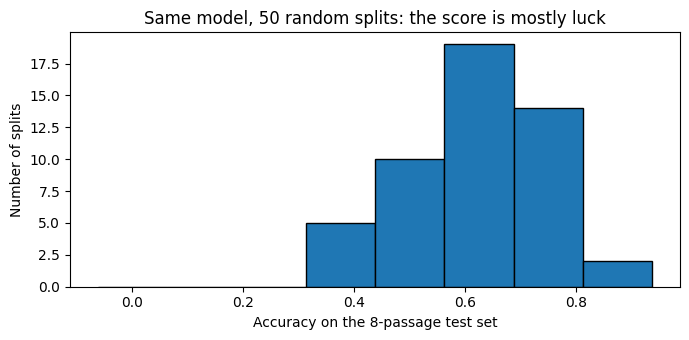

In [4]:
single_split_acc = []
for seed in range(50):
    X_tr, X_te, y_tr, y_te = train_test_split(texts, y, test_size=0.2, random_state=seed, stratify=y)
    m = make_pipeline(TfidfVectorizer(max_features=1000, stop_words="english"),
                      LogisticRegression(max_iter=1000, random_state=SEED))
    m.fit(X_tr, y_tr)
    single_split_acc.append(accuracy_score(y_te, m.predict(X_te)))

single_split_acc = np.array(single_split_acc)
print(f"Test set size: {len(y_te)} passages")
print(f"Accuracy over 50 different splits: min {single_split_acc.min():.3f}, "
      f"max {single_split_acc.max():.3f}, mean {single_split_acc.mean():.3f}")

plt.figure(figsize=(7, 3.5))
plt.hist(single_split_acc, bins=np.arange(0, 1.07, 0.125) - 0.0625, edgecolor="black")
plt.xlabel("Accuracy on the 8-passage test set")
plt.ylabel("Number of splits")
plt.title("Same model, 50 random splits: the score is mostly luck")
plt.tight_layout()
plt.savefig(FIG_DIR / "single_split_variability.png", dpi=150)
plt.show()

## 4. The fix: repeated stratified cross-validation

- **5 folds**: every passage is tested exactly once per round
- **20 repeats**: reshuffle and do it again, giving 100 test results per model
- **Same folds for every model** (same `random_state`), so the comparison is fair
- **Majority baseline**: always guesses the most common label. Any real model must beat this.

**About Sentence-BERT:** turning each passage into an embedding doesn't use labels, so computing
embeddings once for all passages is fine. Only the classifier on top is trained inside the folds.

In [5]:
# Models that work on raw text (TF-IDF is inside the pipeline = no leakage)
text_models = {
    "Majority baseline": DummyClassifier(strategy="most_frequent"),
    "TF-IDF + Logistic Regression": make_pipeline(
        TfidfVectorizer(max_features=1000, stop_words="english"),
        LogisticRegression(max_iter=1000, random_state=SEED)),
    "TF-IDF + Random Forest": make_pipeline(
        TfidfVectorizer(max_features=1000, stop_words="english"),
        RandomForestClassifier(n_estimators=300, random_state=SEED)),
    "TF-IDF + Linear SVM": make_pipeline(
        TfidfVectorizer(max_features=1000, stop_words="english"),
        LinearSVC(random_state=SEED)),
}

# Sentence-BERT embeddings (skipped automatically if the library isn't available)
try:
    from sentence_transformers import SentenceTransformer
    sbert = SentenceTransformer("all-MiniLM-L6-v2")
    X_embed = sbert.encode(texts.tolist(), normalize_embeddings=True, show_progress_bar=False)
    SBERT_OK = True
    print("Sentence-BERT embeddings:", X_embed.shape)
except Exception as e:
    SBERT_OK = False
    print("Sentence-BERT skipped:", e)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Sentence-BERT embeddings: (39, 384)


In [6]:
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=20, random_state=SEED)
scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
}

fold_scores = {}   # model name -> dict of 100 fold scores per metric
for name, model in text_models.items():
    fold_scores[name] = cross_validate(model, texts, y, cv=cv, scoring=scoring)
    print(f"done: {name}")

if SBERT_OK:
    fold_scores["Sentence-BERT + Logistic Regression"] = cross_validate(
        LogisticRegression(max_iter=1000, random_state=SEED), X_embed, y, cv=cv, scoring=scoring)
    print("done: Sentence-BERT + Logistic Regression")

done: Majority baseline
done: TF-IDF + Logistic Regression
done: TF-IDF + Random Forest
done: TF-IDF + Linear SVM
done: Sentence-BERT + Logistic Regression


## 5. Results table

In [7]:
rows = []
for name, s in fold_scores.items():
    row = {"Model": name}
    for metric in ["accuracy", "precision", "recall", "f1"]:
        vals = s[f"test_{metric}"]
        row[f"{metric}_mean"] = round(vals.mean(), 3)
        row[f"{metric}_std"] = round(vals.std(), 3)
    rows.append(row)

results = pd.DataFrame(rows).sort_values("accuracy_mean", ascending=False).reset_index(drop=True)
results.to_csv(RESULTS_DIR / "cross_validation_results.csv", index=False)

# Readable view: mean ± std
view = pd.DataFrame({"Model": results["Model"]})
for metric in ["accuracy", "precision", "recall", "f1"]:
    view[metric] = results[f"{metric}_mean"].map("{:.3f}".format) + " ± " + results[f"{metric}_std"].map("{:.3f}".format)
view

,Model,accuracy,precision,recall,f1
0,TF-IDF + Linear SVM,0.642 ± 0.166,0.639 ± 0.247,0.610 ± 0.291,0.595 ± 0.229
1,TF-IDF + Logistic Regression,0.623 ± 0.151,0.656 ± 0.322,0.453 ± 0.275,0.501 ± 0.249
2,Sentence-BERT + Logistic Regression,0.620 ± 0.162,0.666 ± 0.255,0.525 ± 0.244,0.556 ± 0.207
3,TF-IDF + Random Forest,0.613 ± 0.155,0.644 ± 0.255,0.562 ± 0.250,0.568 ± 0.196
4,Majority baseline,0.514 ± 0.029,0.000 ± 0.000,0.000 ± 0.000,0.000 ± 0.000


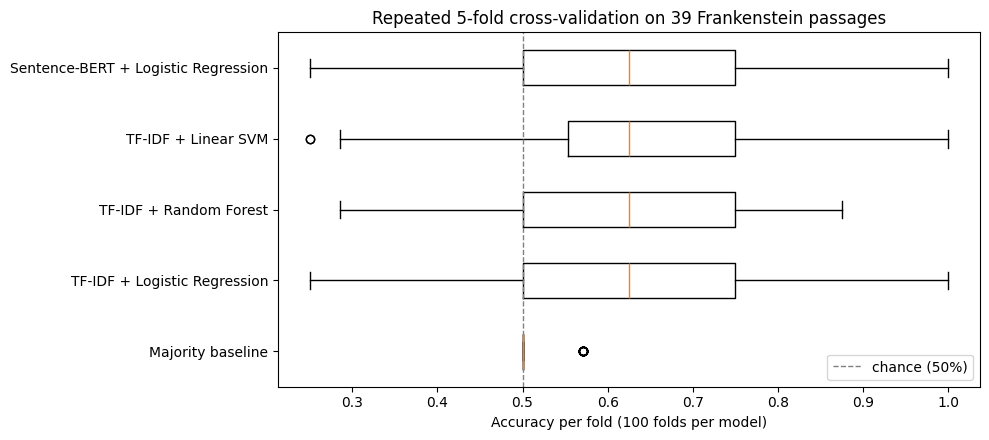

In [8]:
names = list(fold_scores)
data = [fold_scores[n]["test_accuracy"] for n in names]

plt.figure(figsize=(10, 4.5))
try:
    plt.boxplot(data, orientation="horizontal", tick_labels=names)  # newer matplotlib
except TypeError:
    plt.boxplot(data, vert=False, labels=names)                      # older matplotlib
plt.axvline(0.5, color="grey", linestyle="--", linewidth=1, label="chance (50%)")
plt.xlabel("Accuracy per fold (100 folds per model)")
plt.title("Repeated 5-fold cross-validation on 39 Frankenstein passages")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(FIG_DIR / "cv_accuracy_boxplot.png", dpi=150)
plt.show()

### Is Sentence-BERT really better than TF-IDF?

Because every model used the **same folds**, we can compare them fold by fold.

In [9]:
if SBERT_OK:
    a = fold_scores["Sentence-BERT + Logistic Regression"]["test_accuracy"]
    b = fold_scores["TF-IDF + Logistic Regression"]["test_accuracy"]
    diff = a - b
    print(f"Mean difference (SBERT - TF-IDF): {diff.mean():+.3f}")
    print(f"SBERT better in {np.mean(diff > 0):.0%} of folds, "
          f"equal in {np.mean(diff == 0):.0%}, worse in {np.mean(diff < 0):.0%}")
    print("Note: folds overlap, so this is a rough guide, not a formal significance test.")
else:
    print("Sentence-BERT not available in this run.")

Mean difference (SBERT - TF-IDF): -0.003
SBERT better in 36% of folds, equal in 27%, worse in 37%
Note: folds overlap, so this is a rough guide, not a formal significance test.


## 6. Which passages are hardest?

For each passage, we count how often it was misclassified across the 20 repeats.
A passage that's wrong ~100% of the time is worth re-reading. Either the model is weak there,
or **the label itself is debatable**.

In [10]:
def error_rate_per_passage(model, X):
    wrong = np.zeros(len(y))
    tested = np.zeros(len(y))
    X_arr = X if isinstance(X, np.ndarray) else np.asarray(X, dtype=object)
    for train_idx, test_idx in cv.split(X_arr, y):
        model.fit(X_arr[train_idx], y.iloc[train_idx])
        pred = model.predict(X_arr[test_idx])
        wrong[test_idx] += (pred != y.iloc[test_idx].values)
        tested[test_idx] += 1
    return wrong / tested

errors = df[["passage_id", "therapeutic_label", "mechanism", "intensity"]].copy()
errors["error_rate_tfidf_lr"] = error_rate_per_passage(text_models["TF-IDF + Logistic Regression"], texts).round(2)
if SBERT_OK:
    errors["error_rate_sbert_lr"] = error_rate_per_passage(
        LogisticRegression(max_iter=1000, random_state=SEED), X_embed).round(2)
errors["preview"] = texts.str.split().str[:20].str.join(" ") + " ..."

sort_col = "error_rate_sbert_lr" if SBERT_OK else "error_rate_tfidf_lr"
errors = errors.sort_values(sort_col, ascending=False).reset_index(drop=True)
errors.to_csv(RESULTS_DIR / "cv_passage_error_rates.csv", index=False)
errors.head(10)

,passage_id,therapeutic_label,mechanism,intensity,error_rate_tfidf_lr,error_rate_sbert_lr,preview
0,157,0,NaN,0.0,0.05,1.00,"I enjoyed this scene, and yet my enjoyment was..."
1,214,1,Narrative Reconstruction,3.0,0.45,1.00,His tale is connected and told with an appeara...
2,185,1,Narrative Reconstruction,3.0,1.00,1.00,"Still, as I urged our leaving Ireland with suc..."
3,53,0,NaN,0.0,0.25,1.00,"“Justine, you may remember, was a great favour..."
4,78,1,Emotional Catharsis,4.0,0.95,1.00,"I could not answer. “No, Justine,” said Elizab..."
5,77,1,Emotional Catharsis,4.0,1.00,1.00,"She paused, weeping, and then continued, “I th..."
6,217,1,Emotional Catharsis,3.0,0.05,1.00,"My beloved Sister, September 2d. I write to yo..."
7,155,1,Narrative Reconstruction,3.0,0.95,0.95,But in Clerval I saw the image of my former se...
8,43,0,NaN,0.0,0.70,0.95,The summer months passed while I was thus enga...
9,222,1,Narrative Reconstruction,4.0,0.65,0.90,“Yet I cannot ask you to renounce your country...


In [11]:
# Read the annotator notes of the 5 hardest passages: is the label clear-cut?
for pid in errors["passage_id"].head(5):
    row = df[df["passage_id"] == pid].iloc[0]
    print(f"--- Passage {pid} | label {row['therapeutic_label']} | {row['mechanism']}")
    print("Notes:", row.get("annotator_notes", ""), "\n")

--- Passage 157 | label 0 | nan
Notes: The passage presents deep self-reflection about past happiness, present suffering, and future anxiety. Although Victor reconstructs aspects of his identity, the reflection reinforces despair and a sense of personal destruction rather than healing, acceptance, or transformative growth. 

--- Passage 214 | label 1 | Narrative Reconstruction
Notes: The passage represents narrative reconstruction through the recording, correction, and interpretation of Frankenstein's personal history. The process of organizing traumatic experiences into a coherent narrative reflects meaning-making and preservation of personal experience. 

--- Passage 185 | label 1 | Narrative Reconstruction
Notes: The passage represents narrative reconstruction through Victor's recollection of significant life events, including family memories, loss, and personal responsibility. Although dominated by guilt and suffering, the act of reviewing his life history reflects an attempt to pr

## 7. What did the model actually learn? (feature importance, sorted by weight)

We train TF-IDF + Logistic Regression on all 39 passages and look at the biggest weights.
**Watch for character names and plot words.** If they dominate, the model is learning the *story*,
not the *therapeutic function*.

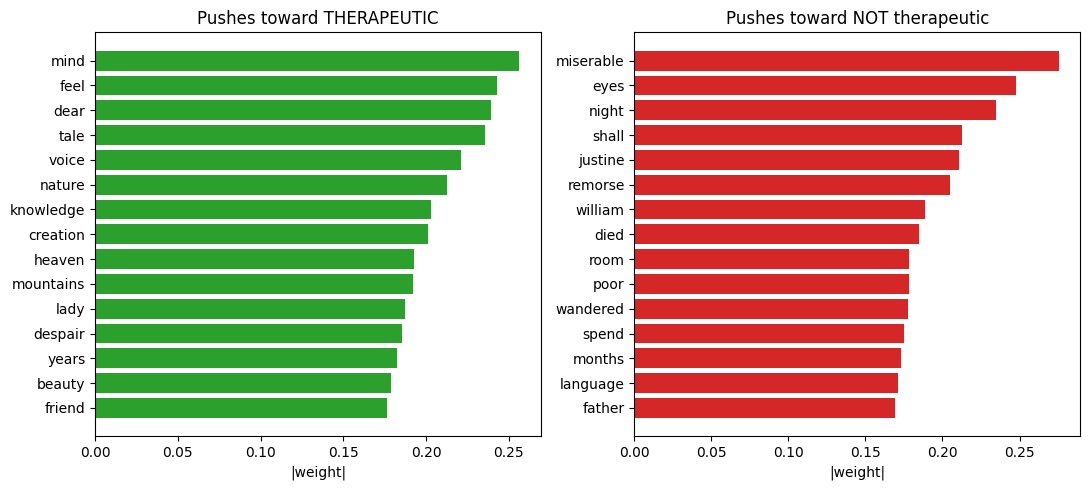

In [12]:
final_model = make_pipeline(TfidfVectorizer(max_features=1000, stop_words="english"),
                            LogisticRegression(max_iter=1000, random_state=SEED))
final_model.fit(texts, y)
vec, clf = final_model.named_steps["tfidfvectorizer"], final_model.named_steps["logisticregression"]

weights = pd.DataFrame({"word": vec.get_feature_names_out(), "weight": clf.coef_[0]})
weights = weights.reindex(weights["weight"].abs().sort_values(ascending=False).index).reset_index(drop=True)
weights.to_csv(RESULTS_DIR / "logistic_feature_importance_sorted.csv", index=False)

top_pos = weights[weights["weight"] > 0].head(15)
top_neg = weights[weights["weight"] < 0].head(15)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].barh(top_pos["word"][::-1], top_pos["weight"][::-1], color="tab:green")
axes[0].set_title("Pushes toward THERAPEUTIC")
axes[1].barh(top_neg["word"][::-1], top_neg["weight"][::-1].abs(), color="tab:red")
axes[1].set_title("Pushes toward NOT therapeutic")
for ax in axes:
    ax.set_xlabel("|weight|")
plt.tight_layout()
plt.savefig(FIG_DIR / "feature_importance_sorted.png", dpi=150)
plt.show()

## 8. ✍️ My interpretation

On a pilot set of 39 annotated passages from Frankenstein (19 therapeutic, 20 non-therapeutic), repeated stratified 5-fold cross-validation with 20 repeats showed that the best-performing model, TF-IDF + Linear SVM, achieved a mean accuracy of 0.642 ± 0.166, compared with a majority baseline of 0.514 ± 0.029. The improvement over baseline suggests that the model captures meaningful linguistic patterns associated with therapeutic representation. However, given the small dataset size and variation across validation folds, these results should be considered exploratory rather than definitive.

## 9. (Colab) Download the outputs

In [13]:
if IN_COLAB:
    import shutil
    from google.colab import files
    shutil.make_archive("cv_results", "zip", RESULTS_DIR)
    files.download("cv_results.zip")
else:
    print("Outputs saved in:", RESULTS_DIR.resolve())

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>